In [ ]:
import networkx as nx
import random as rd
import copy
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import math

## Search on graphs

In [ ]:
# @title
"""
 This file contains the modified DFS algorithm for sampling the feasible trees.
"""
def DFS(G, v, t,k, path, visited, flag=0):
    #Disclaimer: Code refactored with AI assistance.

    # Base Case: Sucess
    #If the current node is the target node and the length of the path - 1 is k, we have found
    #a desired path
    if v == t and len(path) == k:
        return path

    # Base Case: Path too long
    if len(path) > k:
        return None

    # Base Case: Target reached too early
    #If the target node is reached before the length of the desired path, then no path is returned
    if len(path) < k and v == t:
        return None

    # Observed Node Check (Existing "Infection Time" Logic)
    # If we hit a node that was already visited in a previous valid context
    # and the timing matches, we consider this path valid
    if len(path) > 1 and (k -  G.nodes[v]['inf_time'] == len(path) - 1):
        return path

    #If the time doesn't match we return None
    if G.nodes[v]['inf_time'] != math.inf and (k - G.nodes[v]['inf_time'] != len(path) - 1):
        return None

    # Set Infection Time
    # Only set this if it hasn't been set (implied by passing step 4)
    # Each unobserved node we pass in the path receives a infection time.
    if G.nodes[v]['inf_time'] == math.inf:
        G.nodes[v]['inf_time'] = k - len(path) + 1
        reset_inf_time = True #A flag to remember we need to reset it later

    else:
        reset_inf_time = False # We didn't change it

    visited[v] = True

    # Neighbor Handling
    neighbors  = list(G.neighbors(v))

    # Check in case the node doesn't have neighbors:
    if not neighbors:
        visited[v] = False

        #In case we changed the inf time, reset it back to infinite
        if reset_inf_time:
            G.nodes[v]['inf_time'] = math.inf

        return None

    # The flag determines in which ordering the neighbors will be consider
    # The default ordering is 0.
    if flag == 1:
        rd.shuffle(neighbors) #rd.shuffle is an in-place function

    # We shuffle the list, considering the nodes with higher degree
    # may appear first in the list.
    elif flag == 2:
        neighbors_degree = []

        for node in neighbors:
            neighbors_degree.append(G.degree(node))

        norm = sum(neighbors_degree)
        probs = [d/norm for d in neighbors_degree]
        shuffled_list = np.random.choice(neighbors, len(neighbors), replace = False, p=probs)
        neighbors = shuffled_list.tolist()

    # Recursive Step
    for neighbor in neighbors:
        if not visited[neighbor]:
            result = DFS(G, neighbor, t, k, path + [neighbor], visited, flag)
            #If a desired path is returned we return it
            if result:
                return result

    # Backtracking
    #The lines below deals with the process of backtracking in the search
    visited[v] = False
    # Only reset inf_time if We changed it in this specific call
    if reset_inf_time:
        G.nodes[v]['inf_time'] = math.inf


def find_k_length_path(G, s, t, k, flag=0):
    visited = {}
    for node in G.nodes:
        visited[node] = False
    return DFS(G, s, t, k, [s], visited, flag)

def feasible_tree(G, infected_nodes, flag=0):
    tree = []
    for node in infected_nodes:
        tree_aux = find_k_length_path(G, node, 0, G.nodes[node]['inf_time'], flag)
        tree.append(tree_aux)
    return tree

## TreeSampler class

In [ ]:
# @title
"""
Disclaimer: Code refactored with AI assistance, more specifically on code modularization and
verification of edge cases. All final implementation logic, and resulting analysis remain the
original work and responsability of the author.
"""

#Set output prints to a txt file
f = open("output.txt", "a")

class TreeSampler:
    """
    MCMC Sampler for inferring infected nodes on a network with partial
    information available.
    """

    def __init__(self, G, T_initial, infected_nodes, seed=None, flag=0):
        self.G = G
        self.T_current = copy.deepcopy(T_initial)
        self.infected_nodes = infected_nodes
        self.flag = flag

        self.nodes_to_sample = infected_nodes
        self.unobserved_leaves = []
        self.samplings_trees = [T_initial]
        self.log_likelihood_history = []
        #self.beta_history = []

        if seed is not None:
          import random as rd
          rd.seed(seed)
          self.seed = seed

        # Initialization logic
        # Adding intermediate nodes to our list of possible nodes to sample
        for path in T_initial:
            if not path: continue
            for node in path:
                if node not in self.infected_nodes and node not in self.nodes_to_sample:
                    self.nodes_to_sample.append(node)

    def run(self, n_iterations):
        """
        This function executes the Metropolis-Hastings sampling loop.

        Args:
            n_iterations (int): The number of iterations of the loop.

        Returns:
            self.samplings_trees (list): List of states sampled.
        """

        if self.T_current == [[0]]:
            return None

        accepted_count = 0

        #Initialize Beta and Priors
        self.c_prior = 2. #Hyperparameter for Beta prior
        self.d_prior = 5. #Hyperparameter for Beta prior
        self.beta = 0.3 #Initial value for Beta
        #self.beta_history.append(self.beta)

        for _ in tqdm(range(n_iterations), desc="Sampling trees"):
            if not self.nodes_to_sample:
                break

            #self._update_beta_gibbs()
            beta = self.beta

            # Capture full state for reversion
            previous_T = copy.deepcopy(self.T_current)
            previous_G = copy.deepcopy(self.G)
            previous_nodes_list = list(self.nodes_to_sample)
            previous_leaves_list = list(self.unobserved_leaves)

            valid_proposal, q_ratio = self._propose_next_state()

            current_ll = self._prob_tree_log(previous_G, previous_T, beta)
            #self.beta_history.append(self.beta)

            if valid_proposal:
                alpha = self._compute_acceptance_prob(q_ratio, beta, previous_G, previous_T)
                p_uniform = math.log(np.random.uniform())

                if p_uniform < alpha:
                    #ACCEPT
                    accepted_count += 1
                    self.samplings_trees.append(copy.deepcopy(self.T_current))
                    self.log_likelihood_history.append(self._prob_tree_log(self.G, self.T_current, beta))

                else:
                    #REJECT
                    self._revert_state(previous_G, previous_T, previous_nodes_list, previous_leaves_list)
                    self.samplings_trees.append(copy.deepcopy(self.T_current))
                    self.log_likelihood_history.append(current_ll)

            else:
                self._revert_state(previous_G, previous_T, previous_nodes_list, previous_leaves_list)
                self.samplings_trees.append(copy.deepcopy(self.T_current))
                self.log_likelihood_history.append(current_ll)

            #"""
            print(file=f)
            print(f"Current Tree: {self.T_current}", file=f)
            print(file=f)
            print(f"Nodes to sample: {self.nodes_to_sample}",file=f)
            print(file=f)
            print(f"Unobserved leaves: {self.unobserved_leaves}",file=f)
            print(file=f)
            print(f"Current infection times: {nx.get_node_attributes(self.G, "inf_time")}",file=f)
            #"""

        print()
        print(f"Final Acceptance Rate: {accepted_count / n_iterations:.2%}")
        return self.samplings_trees

    # --------- Helper methods ------------ #

    def _propose_next_state(self):
        """
        Handles the logic for proposing a move.

        Returns:
            (bool, float) (tuple) -> (valid_proposal, q_ratio).
        """

        p = np.random.uniform()
        q_ratio = 0 # Default (log(1) = 0)
        valid_proposal = True

        if p < 1/3:
            #Addition
            node_addition = self._choose_random_node(self.nodes_to_sample)
            len_neigh = self._add_neighbor(node_addition)

            if len_neigh is not None and len_neigh > 0:
                # Foward: 1/N_sample_old * 1/len_neigh | Reverse: 1/Leaves_new
                n_sample = len(self.nodes_to_sample) - 1 #The list already includes the new node added
                n_leaves_new = len(self.unobserved_leaves)

                if n_leaves_new > 0:
                    q_ratio = math.log((n_sample *len_neigh)) - math.log(n_leaves_new)

                else:
                    valid_proposal = False

            else:
                valid_proposal = False

        elif p < 2/3:
            #Changing path
            node_change_path = self._choose_random_node(self.infected_nodes)
            self._change_path(node_change_path)

            #We assume the number of available paths doesn't change much between states
            q_ratio = 0 #Assumed symmetric

        else:
            #Deletion
            if len(self.unobserved_leaves) > 0:
                node_delete = self._choose_random_node(self.unobserved_leaves)
                parent_node = self._delete_node(node_delete)
                valid_proposal, q_ratio = self._compute_q_ratio_deletion(parent_node)

            else:
                valid_proposal = False

        return valid_proposal, q_ratio

    def _revert_state(self, prev_G, prev_T, prev_nodes, prev_leaves):
        """
        Clean helper to revert all state components.
        """
        self.G = copy.deepcopy(prev_G)
        self.T_current = copy.deepcopy(prev_T)
        self.nodes_to_sample = list(prev_nodes)
        self.unobserved_leaves = list(prev_leaves)


    def _choose_random_node(self, list_of_nodes):
        """
        Chooses a random element uniformly from a list.

        Args:
            list_of_nodes (list): List with nodes (integers).

        Returns:
            random_node (int): Random element from list_of_nodes.
        """

        rand_idx = rd.randrange(0, len(list_of_nodes))
        random_node = list_of_nodes[rand_idx]

        return random_node

    def _get_path_index_for_node(self, node):
        """
        Gets the index of a specific element in a list.

        Args:
            node (int): The specific element to be found.

        Returns:
            i (int): -1 if element is not found, otherwise the index of node in the list.
        """

        for i, path in enumerate(self.T_current):
            if path and path[0] == node:
                return i
        return -1

    def _is_node_used_in_tree(self, node):
        """
        Checks if an intermediate node is part of any other path in T_current.

        node (int): The node which we want to be checked.
        """
        counter = 0
        for path in self.T_current:
            if node in path:
                counter +=1

        if counter > 0: return True
        else: return False


    def _calculate_new_path(self,source_node):
        """
        Finds a path of fixed length from a source node to a target node.

        Args:
            source_node (int): Source node for the s-t k-path search.

        Returns:
            new_path (list): s-t k-path found.
        """

        new_path = find_k_length_path(
            self.G, source_node, 0, self.G.nodes[source_node]['inf_time'], self.flag
        )

        return new_path

    def _assign_and_track_new_path(self, index, new_path):
        """
        Assign a new_path for node in a given index.

        Args:
            index (int): Index of the node that is the source of the new path.
            new_path (list): Path of fixed length from a source node to a target node.
        """

        self.T_current[index] = new_path

        #Clean up tracking lists
        for n in new_path:
            #If a leaf becomes part of a path for the new_node, it is no longer a leaf
            if n in self.unobserved_leaves:
                self.unobserved_leaves.remove(n)

            if n not in self.nodes_to_sample:
                self.nodes_to_sample.append(n)

    def _is_ancestor_to_any_node(self, node):
        """
        Helper to check if 'node' acts as a ancestor to any other node in T_current.

        Args:
            node (int): Node that will be check if it has any child.

        Returns:
            (bool) : True or False.
        """
        for path in self.T_current:
            # Assuming path structure is [Child, Parent, ...]
            # If the path has a parent at index 1, and that parent is 'node'
            if len(path) > 1:
                for i in path[1:]:
                    if path[i] == node:
                        return True
        return False

    # ---------- Operations function --------------- #
    def _change_path(self, target_node):
        """
        This function performs a change of path operation.

        Args:
            target_node (int): The node for which the path in the current tree will be changed.
        """
        print("Changing path",file=f)
        t_index = self._get_path_index_for_node(target_node)

        if t_index == -1: return

        old_path = list(self.T_current[t_index])

        if len(old_path) > 1:
            old_parent = old_path[1]
        else:
            old_parent = None

        new_path = self._calculate_new_path(target_node)

        #if new_path[1] == old_path[1]:
        #    return

        if new_path is not None:
            self._assign_and_track_new_path(t_index, new_path)

            if old_parent is not None:
                if not self._is_node_used_in_tree(old_parent):

                    if old_parent not in self.unobserved_leaves:
                        self.unobserved_leaves.append(old_parent)

                    self.T_current.append(old_path[1:])


    def _add_neighbor(self, node):
        """
        Performs an addition of a node operation.

        Args:
            node (int): The parent of the new node that will be added.

        Returns:
            len_neighb_available (int): The size of the list of available neighbors of the
            parent node that can be added in the tree.
        """

        neighbors = list(self.G.neighbors(node))
        neighb_available = [node for node in neighbors if self.G.nodes[node]['inf_time'] == math.inf]

        if not neighb_available: return None

        new_node =  neighb_available[rd.randrange(0, len( neighb_available))]

        print(f"New node added: {new_node}",file=f)
        self.G.nodes[new_node]['inf_time'] = self.G.nodes[node]['inf_time'] + 1

        #Update state
        self.T_current.append([new_node, node])
        self.nodes_to_sample.append(new_node)
        self.unobserved_leaves.append(new_node)

        #If the source was a leaf, it is not anymore
        if node in self.unobserved_leaves:
            self.unobserved_leaves.remove(node)

        len_neighb_available = len(neighb_available)

        return len_neighb_available

    def _delete_node(self, node):
        """
        Performs a deletion of a node operation.

        Args:
            node (int): The node which will be deleted from the current feasible tree.

        Returns:
            parent_node (int or None): The parent of the deleted node in the current feasible tree.
        """
        t_index = self._get_path_index_for_node(node)
        if t_index == -1: return None

        current_path = list(self.T_current[t_index])

        #The path structure is [Leaf, Parent] based on _add_neighbor logic.
        # Hence the parent is at index 1.
        if len(current_path) > 1: parent_node = current_path[1]
        else: parent_node = None

        #Reset infection time for deleted node
        self.G.nodes[node]['inf_time'] = math.inf
        print({f"Node deleted: {node}"},file=f)

        if node in self.nodes_to_sample:
            self.nodes_to_sample.remove(node)

        if node in self.unobserved_leaves:
            self.unobserved_leaves.remove(node)

        del self.T_current[t_index]

        #Handle the parent node
        if parent_node is not None:
            if not self._is_node_used_in_tree(parent_node):
                retained_path = current_path[1:]

                if len(retained_path) > 0:
                    self.T_current.append(retained_path)


        if not self._is_ancestor_to_any_node(parent_node):
            if parent_node not in self.unobserved_leaves:
                if parent_node not in self.infected_nodes:
                    self.unobserved_leaves.append(parent_node)

            if parent_node not in self.nodes_to_sample:
                self.nodes_to_sample.append(parent_node)

        return parent_node

    # ---------- Compute probabilities -------------------#
    def _prob_tree_log(self, G, T, beta):
        """
        This function calculates the log-likelihood of a tree for a given infection rate.

        Args:
            G (networkx graph): Graph for which we will calculate the failed infection events.
            T (list): The transmission tree for which we will compute the log-likelihood.
            beta (float): Infection rate.

        Returns:
            prob_log (float): The log-likelihood for T for a fixed beta.
        """

        #Identify all nodes in the tree
        nodes_in_tree = set()
        for path in T:
            for node in path:
                nodes_in_tree.add(node)

        if len(nodes_in_tree) <= 1:
            return 0

        # Succes Events (V_T - 1)
        succes_events = len(nodes_in_tree) - 1
        failed_events = 0

        for u in nodes_in_tree:
            for v in G.neighbors(u):
                if v not in nodes_in_tree:
                    failed_events += 1


        log_beta = math.log(max(1e-9, beta))
        log_beta_aux = math.log(max(1e-9, 1 - beta)) # Use 1-beta here

        prob_log = succes_events * log_beta + failed_events * log_beta_aux

        #"""
        print(f"Current beta: {beta}",file=f)
        print(f"Succes events: {succes_events}",file=f)
        print(f"Failed events: {failed_events}",file=f)
        print(f"prob_log: {prob_log}",file=f)
        #"""

        return prob_log

    def _compute_acceptance_prob(self, q_ratio, beta, previous_G, previous_T):
        """
        Calculates alpha using the log-likelihoods

        Args:
            q_ratio (float): Proposal distribution ratio.
            beta (float): Infection rate.
            previous_G (networkx graph): Graph G before proposal.
            previos_T (list): Feasible tree before proposal.

        Returns:
            alpha (float): Acceptance probability for proposal.
        """

        prob_tree_prop = self._prob_tree_log(self.G, self.T_current, beta)
        prob_tree_curr = self._prob_tree_log(previous_G, previous_T, beta)

        # Alpha = (Log P_new - Log P_old) + Log Q_ratio
        alpha_aux = prob_tree_prop - prob_tree_curr + q_ratio

        alpha = min(0, alpha_aux)
        return alpha

    def _compute_q_ratio_deletion(self, parent_node):
        """
        Calculates the Hastings ratio for deletion

        Args:
            parent_node (int): The parent node of the deleted node.

        Returns:
            (bool, float) -> (valid_proposal, q_ratio)
        """

        valid_proposal = False
        q_ratio = 0

        if parent_node is not None:

            neigh_available = 0

            # Recalculate available neighbors for the reverse move (Addition)
            for neighbor in self.G.neighbors(parent_node):

                if self.G.nodes[neighbor]['inf_time'] == math.inf:
                    neigh_available += 1

            n_sample_new = len(self.nodes_to_sample)

            # Check for the Math Domain Error condition (Denominator must be non-zero)
            if n_sample_new == 0 or neigh_available == 0:
                valid_proposal = False

            else:
                # q(T|T') / q(T'|T) = N_leaves_old / (N_sample_new * neigh_available)
                n_leaves_old = len(self.unobserved_leaves) + 1
                q_ratio = math.log(n_leaves_old) - math.log(n_sample_new) - math.log(neigh_available)
                valid_proposal = True

        else:
            # Deletion failed
            valid_proposal = False

        return valid_proposal, q_ratio

    # ---------------- Visualise results ------------------------- #
    def _trace_plot_log_likelihood(self):
        """
        Plots the trace plot for the log likelihood of the samplings.
        """
        if len(self.log_likelihood_history) <= 1:
            print("No valid sampling has been performed yet!")
        else:
            plt.figure(figsize=(10, 5))
            plt.plot(self.log_likelihood_history)
            #plt.title("Log-Likelihood Trace")
            plt.xlabel("Iteration")
            plt.ylabel("Log-Likelihood")
            plt.show()

    def _trace_plot_beta(self):
        """
        Plots the trace plot for the beta variable.
        """
        if len(self.beta_history) <= 1:
            print("No valid sampling has been performed yet!")
        else:
            plt.figure(figsize=(10, 5))
            plt.plot(self.beta_history)
            #plt.axhline(y= stat.mean(self.beta_history), color='g', linestyle='-')
            plt.xlabel("Iteration")
            plt.ylabel(r"$\beta$")
            plt.show()

    def _size_of_the_tree(self, T):
        """
        Calculates the size of a tree.

        Args:
            T (list): A list of lists with the paths of the tree.

        Returns:
           tree_size (int): Returns the size of the tree |V_T|
        """
        #Identify all nodes in the tree
        nodes_in_tree = set()
        for path in T:
            nodes_in_tree.update(path)

        tree_size = len(nodes_in_tree)

        return tree_size

    def _trace_plot_tree_size(self):
        return None

    # ----------------- Beta (Gibbs update) ------------- #
    def _get_tree_statistics(self, G, T):
        """
        Computes the N_success and N_fail in a given tree for the Gibbs step.

        Args:
            G (networkx graph): A graph G that we are sampling from.
            T (list): A list of lists with the paths of the tree.

        Returns:
           n_success, n_fail  (int, int): Number of sucessfull and failed
           transmission events for T.
        """

        nodes_in_tree = set()
        for path in T:
            for node in path:
                nodes_in_tree.add(node)

        if len(nodes_in_tree) <= 1:
            return 0

        # Succes Events (V_T - 1)
        n_success = len(nodes_in_tree) - 1
        n_fail = 0

        for u in nodes_in_tree:
            for v in G.neighbors(u):
                if v not in nodes_in_tree:
                    n_fail += 1

        #"""
        print("Tree statistics:",file=f)
        print(f"n_sucess: {n_success}" ,file=f)
        print(f"n_fail: {n_fail}",file=f)
        #"""

        return n_success, n_fail

    def _update_beta_gibbs(self):
        """
        Performs the Gibbs update step for the beta parameter.
        P(beta | T) ~ Beta(alpha_prior + N_success, beta_prior + N_fail)
        """

        n_success, n_fail = self._get_tree_statistics(self.G, self.T_current)
        c_posterior = self.c_prior + n_success
        d_posterior = self.d_prior + n_fail

        new_beta = np.random.beta(c_posterior, d_posterior)
        self.beta = max(1e-9, min(new_beta, 1 - 1e-9))


    # ------------- Performs Naive Sampling ---------------- #
    def naive_sampling(G, sampling_number, observed_nodes, initial_infecteds):
        samplings = []
        G_mutable = copy.deepcopy(G)

        while len(samplings) < sampling_number:

            p = np.random.uniform()

            #In place modification of G
            fast_SIR(G_mutable, initial_infecteds, p)

            if check_feasibility_graphs(G, G_mutable, observed_nodes):
                all_nodes = nx.get_node_attributes(G_mutable, "inf_time")
                nodes_infected = [node for node, inf_time in all_nodes.items() if inf_time < math.inf]

                samplings.append(nodes_infected)

        return samplings


Our initial verification test uses the path 0 -> 1 -> 2

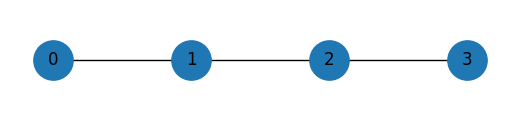

In [ ]:
e = [(0,1), (1,2), (2,3)] #list of edges
G = nx.Graph(e)

pos = {0: [0,0], 1: [1,0], 2: [2,0], 3: [3,0]}
fig = plt.figure(1, figsize=(5, 1))
nx.draw(G, with_labels= True, pos=pos, node_size= 800)

Setting attribute to account for the real epidemics in the graph

In [ ]:
attrs = {0: {"inf_time": 1, "status": 'recovered'}, 1: {"inf_time": 2, "status": 'recovered'},
         2: {"inf_time": 3, "status": 'recovered'}, 3: {"inf_time": math.inf, "status": 'susceptible'}}
nx.set_node_attributes(G, attrs)

Visualizing the graph with their respectives infection times


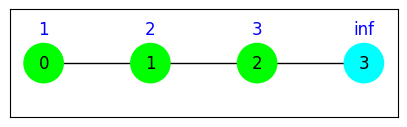

In [ ]:
color_state_map = {'recovered': 'lime', 'susceptible': 'cyan'}
node_color = [color_state_map[node[1]['status']] for node in G.nodes(data=True)]

infection_times = nx.get_node_attributes(G, "inf_time")
state_pos = {n: (x, y + 0.035) for n, (x,y) in pos.items()}

fig = plt.figure(1, figsize=(5, 1.4))
nx.draw_networkx(G, pos, node_size = 800, node_color = node_color,)

nx.draw_networkx_labels(G, state_pos, labels= infection_times, font_color='blue')
plt.show()

Partial information available

In [ ]:
#First we make a copy of G with the real infection times
G_real = copy.deepcopy(G)

In [ ]:
#We exclude the information for nodes 2 and 3
nx.set_node_attributes(G, {2: {"inf_time": math.inf, "status": None}, 3: {"inf_time": math.inf, "status": None}})

Visualizing the graph with only the partial information available

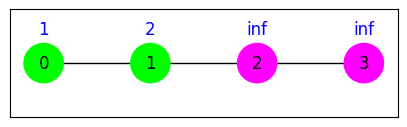

In [ ]:
color_state_map = {'recovered': 'lime', 'susceptible': 'cyan', None: 'magenta'}
node_color = [color_state_map[node[1]['status']] for node in G.nodes(data=True)]

infection_times = nx.get_node_attributes(G, "inf_time")
state_pos = {n: (x, y + 0.035) for n, (x,y) in pos.items()}

fig = plt.figure(1, figsize=(5, 1.4))
nx.draw_networkx(G, pos, node_size = 800, node_color = node_color,)

nx.draw_networkx_labels(G, state_pos, labels= infection_times, font_color='blue')
plt.show()

In [ ]:
#Copying the partial information to use different sample sizes
G_10000 = copy.deepcopy(G)
G_100000 = copy.deepcopy(G)

Set an initial feasible tree for G given the observed values

In [ ]:
# The feasible tree data structure is a list of lists
# Each element in T_initial is a path in the tree
T_initial = feasible_tree(G, [0,1], flag=1)
print(T_initial)

[[0], [1, 0]]


Returns the frequency (in %) of the nodes in the sampling

In [ ]:
# @title
def nodes_proportion(G, samplings):
    """
    Returns the proportion of each node in a sampling of feasible trees in the format
    of list of lists.
    """

    if samplings == None:
        return

    nodes_prop = {x: 0 for x in list(G.nodes)}
    for node in G.nodes:
        for lis in samplings:
            is_present = any(node in sublist for sublist in lis)
            nodes_prop[node] += is_present

    n = len(samplings)

    for node in nodes_prop:
        nodes_prop[node] = nodes_prop[node]/ n
    return nodes_prop

Start the sampling algorithm

(at each run we plot information about the current tree, choosed operations and so forth in order to manually verify the correctness of the outputs, see output.txt file)

In [ ]:
infected_nodes = [0,1]
samplings_number = 1000

#Initialize class
sampler_1000 = TreeSampler(G, T_initial, infected_nodes, seed=10, flag=1)

#Run
sampling = sampler_1000.run(n_iterations=samplings_number)
print(f"Real infection times: {nx.get_node_attributes(G_real, "inf_time")}")
print("--------------------------------------------------------------------------------------------")
print(f"Frequency of nodes: {nodes_proportion(G, sampling)}")

Sampling trees: 100%|██████████| 1000/1000 [00:00<00:00, 4636.30it/s]


Final Acceptance Rate: 53.70%
Real infection times: {0: 1, 1: 2, 2: 3, 3: inf}
--------------------------------------------------------------------------------------------
Frequency of nodes: {0: 1.0, 1: 1.0, 2: 0.24075924075924077, 3: 0.04295704295704296}


In [ ]:
samplings_number = 10000

sampler_10000 = TreeSampler(G_10000, T_initial, infected_nodes, seed=10,flag=1)

#Run
sampling = sampler_1000.run(n_iterations=samplings_number)
print(f"Real infection times: {nx.get_node_attributes(G_real, "inf_time")}")
print("--------------------------------------------------------------------------------------------")
print(f"Frequency of nodes: {nodes_proportion(G_10000, sampling)}")

Sampling trees: 100%|██████████| 10000/10000 [00:03<00:00, 2945.47it/s]


Final Acceptance Rate: 52.09%
Real infection times: {0: 1, 1: 2, 2: 3, 3: inf}
--------------------------------------------------------------------------------------------
Frequency of nodes: {0: 1.0, 1: 1.0, 2: 0.2852467957458413, 3: 0.0684483228797382}


In [ ]:
samplings_number = 100000

sampler_100000 = TreeSampler(G_100000, T_initial, infected_nodes,seed=10, flag=1)

#Run
sampling = sampler_100000.run(n_iterations=samplings_number)
print(f"Real infection times: {nx.get_node_attributes(G_real, "inf_time")}")
print("--------------------------------------------------------------------------------------------")
print(f"Frequency of nodes: {nodes_proportion(G_100000, sampling)}")

Sampling trees: 100%|██████████| 100000/100000 [00:15<00:00, 6545.82it/s]



Final Acceptance Rate: 52.09%
Real infection times: {0: 1, 1: 2, 2: 3, 3: inf}
--------------------------------------------------------------------------------------------
Frequency of nodes: {0: 1.0, 1: 1.0, 2: 0.2827771722282777, 3: 0.07041929580704193}


### Plots (visualizing results)
Trace plot (still in progress)

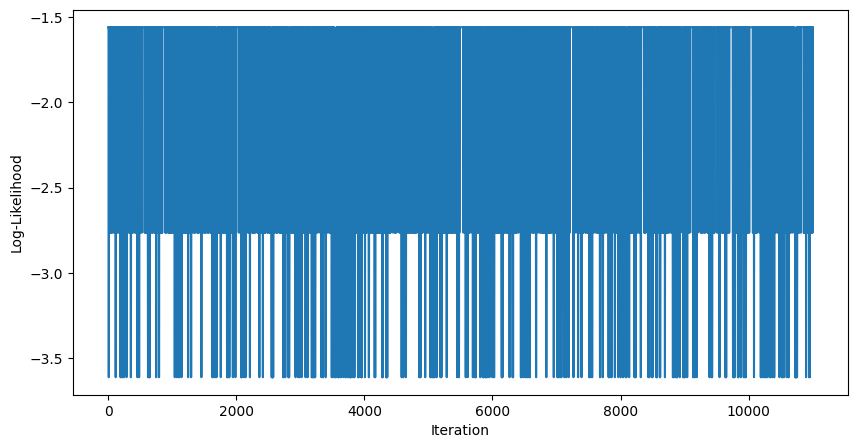

In [ ]:
sampler_1000._trace_plot_log_likelihood()

## Next step: Convergence diagnostics

ref: https://arxiv.org/pdf/1909.11827